## <b>Homogeneous Laplacian Experiment</b>

### Study Motivation:

In this section we assess the performance of <b>multilevel SWIM-PDE</b> (SWIM-PDE-MLDD). In particular, we investigate the accuracy of using SWIM-PDE-MLDD to solve 2D homogeneous Laplacian problem in function approximation setting, and compare it with <b>onelevel SWIM-PDE</b> (SWIM-PDE-DD).

In particular, we assess how varying the <b>number of levels</b> and
<b>subdomains</b> as well as the <b>overlap ratio</b> and <b>size of the subdomain networks</b> (architecture) affects the SWIM-PDE-MLDD performance.

<b>Note:</b> In the regular PDE solving setup we have to approximate the <b>f(x)</b> (RHS equation in the given problem; <b>0</b> in this case) by evaluating the each individual operators in LHS of the equation. 

---
### Problem Definition:
We consider the following 2D homogeneous Laplacian problem:

$$
-\Delta u = f \quad \text{in } \Omega = [0, 1]^2, \quad u = 0 \quad \text{on } \partial \Omega
$$

where the source term is defined as:

$$
f(x_1, x_2) = 32 \cdot \left( x_1 \cdot (1 - x_1) + x_2 \cdot (1 - x_2) \right)
$$

The exact solution is given by:

$$
u(x_1, x_2) = 16 \cdot x_1 \cdot (1 - x_1) \cdot x_2 \cdot (1 - x_2)
$$

---
### Parametric Setup:

All models are trained with <b>80 x 80 = 6400</b> collocation points and tested with <b>350 x 350 = 122500</b> points uniformly spaced on the domain <b>$[0, 1]^2$</b>.

As mentioned above try to observe the effects of following parameters by keeping the other parameters same for the test:

<b><u>Overlapping Ratio Experiment:</u></b> We change the <b>overlapping ratio from 0.1 to 0.9</b> while using <b>L=3 SWIM-PDE-MLDD model with 1x1, 2x2, 4x4 partitions</b> for each level. Each subdomain SWIM network has <b>16 tanh basis functions</b>.

<b><u>Local Network Capacity Experiment:</u></b> We change the number of <b>tanh basis function</b> from <b>2 to 32</b> while using <b>L=3 SWIM-PDE-MLDD model with 1x1, 2x2, 4x4 partitions</b> for each level with <b>0.5 overlapping ratio</b>.

<b><u>Number of Subdomain and Level Experiment:</u></b> We change the number of subdomains for different levels from <b>L=2 to 5</b> with <b>$2^{(D \cdot (L-1))}$ subdomains for each level</b> for SWIM-PDE-MLDD. We also train multiple SWIM-PDE-DD with same partitions of the last levels of SWIM-PDE-MLDD. During this test each subdomain SWIM network has <b>16 tanh basis functions</b>. 

---

### Loss Function:
The normalized L1 loss function is defined as:

$$
\mathcal{L}(\theta) = \frac{1}{M} \sum_{i=1}^{M} \frac{\left\| u(x_i, \theta) - u(x_i) \right\|}{\sigma}
$$

- $M$ is the number of test points  
- $u(x_i, \theta)$ is the predicted solution at point $x_i$
- $u(x_i)$ is the exact solution at point $x_i$
- $\sigma$ is the standard deviation of the exact solution values ${u(x_i)}_{i}^{M}$

---


#### Common Module Imports

In [8]:

import numpy as np
import numpy.typing as npt
import jax.numpy as jnp
from jax.typing import ArrayLike

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from functools import partial

We define the explained problems programmatically as following:

In [9]:
# Target and forcing functions and problem parameters definition
def homogeneous_laplacian(x: npt.ArrayLike):
    """
    Computes the exact solution u(x1, x2) = 16 * x1 * (1 - x1) * x2 * (1 - x2)
    for a batch of input points.

    Parameters:
        x (np.ndarray): Array of shape (N, 2), where each row is [x1, x2]

    Returns:
        np.ndarray: Array of shape (N,) with the exact solution at each point
    """
    
    x1 = x[:, 0]
    x2 = x[:, 1]
    
    return (16 * x1 * (1 - x1) * x2 * (1 - x2))[:, None]

def homogeneous_laplacian_forcing(x: npt.ArrayLike):
    """
    Computes the forcing function f(x1, x2) = 32 * ((x1 * (1 - x1)) + (x2 * (1 - x2)))
    for a batch of input points.

    Parameters:
        x (np.ndarray): Array of shape (N, 2), where each row is [x1, x2]

    Returns:
        np.ndarray: Array of shape (N,) with the exact solution at each point
    """
    
    x1 = x[:, 0]
    x2 = x[:, 1]
    
    return (32 * ((x1 * (1 - x1)) + (x2 * (1 - x2))))[:, None]

def constraining_operator(points: ArrayLike, sigma=0.2) -> ArrayLike:
    """
    [Cu](x) = tanh(x1/σ) tanh((1−x1)/σ) tanh(x2/σ) tanh((1−x2)/σ)
    """
    x, y = points[0], points[1]
    return (
        jnp.tanh(x / sigma) *
        jnp.tanh((1 - x) / sigma) *
        jnp.tanh(y / sigma) *
        jnp.tanh((1 - y) / sigma)
    )

The training and test datasets are defined as following:

In [10]:
# Experiment definition
RANDOM_STATE = 17 # for result reproducibility
rng = np.random.default_rng(seed=RANDOM_STATE)

# Domain definition
SPAN = [
    (0, 1), # x span
    (0, 1)  # y span
]

N_DIM = len(SPAN)

# Dataset definition
NUM_TRAIN_POINTS_PER_DIM = 80
NUM_TEST_POINTS_PER_DIM = 350

# Dataset creation
x_train = np.linspace(SPAN[0][0], SPAN[0][1],  NUM_TRAIN_POINTS_PER_DIM)
y_train = np.linspace(SPAN[1][0], SPAN[1][1],  NUM_TRAIN_POINTS_PER_DIM)
train_inputs = np.stack(np.meshgrid(x_train, y_train), axis=-1).reshape(-1, N_DIM)
train_targets = homogeneous_laplacian(train_inputs)

x_test = np.linspace(SPAN[0][0], SPAN[0][1],  NUM_TEST_POINTS_PER_DIM)
y_test = np.linspace(SPAN[1][0], SPAN[1][1],  NUM_TEST_POINTS_PER_DIM)
test_inputs = np.stack(np.meshgrid(x_test, y_test), axis=-1).reshape(-1, N_DIM)
test_targets = homogeneous_laplacian(test_inputs)

boundary_mask = (
        (train_inputs[:, 0] == SPAN[0][0]) |
        (train_inputs[:, 0] == SPAN[0][1]) |
        (train_inputs[:, 1] == SPAN[1][0]) |
        (train_inputs[:, 1] == SPAN[1][1])  
    )

Exact solution of test set looks like as below:

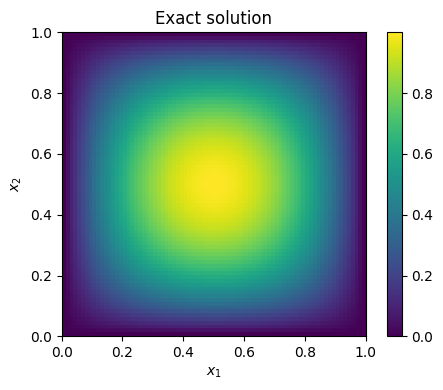

In [11]:
# Plotting exact solution
def plot_laplacian(x: npt.ArrayLike):
    fig, ax = plt.subplots(figsize=(5, 4))
    vmin = np.nanmin(x)
    vmax = np.nanmax(x)
    im = ax.imshow(x, extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
    ax.set_title("Exact solution")
    plt.xlabel(r'$x_1$')
    plt.ylabel(r'$x_2$')
    fig.colorbar(im, ax=ax, orientation='vertical')
    plt.tight_layout()
    plt.show()
    
plot_laplacian(train_targets.reshape(NUM_TRAIN_POINTS_PER_DIM, -1))

##### Model Related Imports

In [12]:
from swimpde_jax.domain import MultiLevelDecomposedDomain
from swimpde_jax.solver import DomainDecomposedStaticSolver
from swimpde_jax.ansatz import DecomposedBasicAnsatz
from swimpde_jax.boundary import ZeroDirichlet
from swimpde_jax.equation import Laplacian

##### Base Model Parameter Definitions

In [13]:
# Common parameter definitions
ACTIVATION_FUNCTION = "tanh"
PARAMETER_SAMPLER = "random"
REGULARIZATION_SCALE = 1e-12
SWIM_SVD_CUTOFF= 1e-12
WINDOW_FUNCTION = "cosine"
SOLVER ="lstsq"

# Base model specific parameters
BASE_MODEL_NUM_BASIS = 16
BASE_MODEL_PARTITION = [1, 2, 4] # L = 3
BASE_MODEL_OVERLAP_RATIO = 1.9

##### Helper Function Definitions

In [14]:
# Helper function for calculating the total number of subdomains
def find_number_of_subdomains(partitioning, n_dim=2) -> int:
    """Calculates number of subdomains given the partitioning and number of dimension

    Args:
        partitioning (list[int]): partitioning per level per axis
        n_dim (int, optional): problem dimension. Defaults to 2.

    Returns:
        int: number of subdomains
    """
    num_subdomains = 0
    for partition in partitioning:
        num_subdomains += partition ** n_dim
    
    return num_subdomains

#### <b>1.1. Overlapping Ratio Experiment</b>

For this experiment we will evaluate the effects of using different overlapping ratios between 1.1, 1.5, 1.9, 2.3, 2.7 on the prediction accuracy using the based SWIM-PDE-MLDD model with L=2.

In [15]:
overlapping_configs = {}
for overlapping_ratio in range(11, 30, 4):
    overlapping_configs[float(overlapping_ratio)/10] = {}
print(overlapping_configs)

{1.1: {}, 1.5: {}, 1.9: {}, 2.3: {}, 2.7: {}}


##### Training and Inference

In [16]:
for overlap_ratio, log in overlapping_configs.items():
    # Domain Definition
    # Note1: Based on the partitioning definition MultiLevelDecomposedDomain can perform both onelevel or multilevel approaches. e.g: [2] or [1, 2]
    domain = MultiLevelDecomposedDomain(
        interior_points=train_inputs[~boundary_mask],
        boundary_points=train_inputs[boundary_mask],
        overlap_ratio=overlap_ratio,
        num_partition_per_level=BASE_MODEL_PARTITION,
        window_fn=WINDOW_FUNCTION,
    )

    # Equation Definition
    equation = Laplacian()
    
    # Forcing function and boundary condition definition
    forcing_function = homogeneous_laplacian_forcing
    boundary_condition = ZeroDirichlet()
    
    # Ansatz definition 
    ansatz = DecomposedBasicAnsatz(
        n_basis=BASE_MODEL_NUM_BASIS,
        activation=ACTIVATION_FUNCTION,
        random_seed=RANDOM_STATE,
        svd_cutoff=SWIM_SVD_CUTOFF,
        constraining_operator=partial(constraining_operator, sigma=0.2),
        parameter_sampler=PARAMETER_SAMPLER,
    )
    
    # Solver definition
    solver = DomainDecomposedStaticSolver(
        domain=domain,
        ansatz=ansatz,
        boundary_condition=boundary_condition,
        equation=equation,
        f=forcing_function, 
        regularization_scale=REGULARIZATION_SCALE,
        solver=SOLVER,
        use_disk=False,
    )
    # Training
    solver.fit()
    # Inference
    swim_prediction, level_based_swim_predictions, _= solver.evaluate(test_inputs)
    
    # Logging
    log['prediction'] = swim_prediction
    log['loss'] = mean_absolute_error(swim_prediction, test_targets)

Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 3/3 [00:16<00:00,  5.54s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 3/3 [00:15<00:00,  5.11s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
Initializing local SWIM networks...


...

All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 3/3 [00:16<00:00,  5.48s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 3/3 [00:15<00:00,  5.27s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.


#### Final Prediction Comparison

In [17]:
num_subdomains = find_number_of_subdomains(partitioning=BASE_MODEL_PARTITION, n_dim=N_DIM)
for overlap, log in overlapping_configs.items():
    print(f"For the overlapping ratio = {overlap} MAE lost is {log['loss']}.")

For the overlapping ratio = 1.1 MAE lost is 0.03962777436014155.
For the overlapping ratio = 1.5 MAE lost is 2.3012876590323918e-05.
For the overlapping ratio = 1.9 MAE lost is 1.5682799667601424e-06.
For the overlapping ratio = 2.3 MAE lost is 2.858882195932383e-07.
For the overlapping ratio = 2.7 MAE lost is 2.8430142774445423e-08.


#### Evaluation

We observe that increasing the overlapping ratio reduces the prediction error.

#### <b>1.2. Local Network Capacity Experiment</b>

For this experiment we will change number of basis functions from 2 to 32 to evaluate the effects of local network capacities on the accuracy using the base model with L=2 and overlapping ratio = 1.3

In [18]:
basis_configs = {}
for basis_exponent in range(1, 6):
    basis_configs[2**basis_exponent] = {}
print(basis_configs)

{2: {}, 4: {}, 8: {}, 16: {}, 32: {}}


##### Training and Inference

In [19]:
for num_basis, log in basis_configs.items():
    # Domain Definition
    # Note1: Based on the partitioning definition MultiLevelDecomposedDomain can perform both onelevel or multilevel approaches. e.g: [2] or [1, 2]
    domain = MultiLevelDecomposedDomain(
        interior_points=train_inputs[~boundary_mask],
        boundary_points=train_inputs[boundary_mask],
        overlap_ratio=BASE_MODEL_OVERLAP_RATIO,
        num_partition_per_level=BASE_MODEL_PARTITION,
        window_fn=WINDOW_FUNCTION,
    )
    # Equation Definition
    equation = Laplacian()
    
    # Forcing function and boundary condition definition
    forcing_function = homogeneous_laplacian_forcing
    boundary_condition = ZeroDirichlet()
    
    # Ansatz definition 
    ansatz = DecomposedBasicAnsatz(
        n_basis=num_basis,
        activation=ACTIVATION_FUNCTION,
        random_seed=RANDOM_STATE,
        svd_cutoff=SWIM_SVD_CUTOFF,
        constraining_operator=partial(constraining_operator, sigma=0.2),
        parameter_sampler=PARAMETER_SAMPLER,
    )
    
    # Solver definition
    solver = DomainDecomposedStaticSolver(
        domain=domain,
        ansatz=ansatz,
        boundary_condition=boundary_condition,
        equation=equation,
        f=forcing_function, 
        regularization_scale=REGULARIZATION_SCALE,
        solver=SOLVER,
        use_disk=False,
    )
    # Training
    solver.fit()
    # Inference
    swim_prediction, level_based_swim_predictions, _ = solver.evaluate(test_inputs)
    
    # Logging
    log['prediction'] = swim_prediction
    log['loss'] = mean_absolute_error(swim_prediction, test_targets)

Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 3/3 [00:15<00:00,  5.20s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 3/3 [00:15<00:00,  5.07s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
Initializing local SWIM networks...


...

All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 3/3 [00:15<00:00,  5.24s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 3/3 [00:15<00:00,  5.29s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.


#### Final Prediction Comparison

In [20]:
for num_basis, log in basis_configs.items():
    print(f"For {num_basis} local network tanh basis functions the MAE loss is {log['loss']}.")

For 2 local network tanh basis functions the MAE loss is 0.04180023884608876.
For 4 local network tanh basis functions the MAE loss is 0.011488397031516936.
For 8 local network tanh basis functions the MAE loss is 0.0005775464080304012.
For 16 local network tanh basis functions the MAE loss is 1.5682799667601424e-06.
For 32 local network tanh basis functions the MAE loss is 1.247074847123021e-08.


#### Evaluation

We observe that increasing the number of basis for each local network reduces the global prediction capacity within the given range from 2 to 32.

#### <b>1.3. Number of Subdomains and Levels Experiment</b>

For this experiment we will evaluate the following SWIM-PDE-MLDD and SWIM-PDE-DD configurations:

In [21]:
partitioning_configs = {
    'SWIM_PDE_DD' : {
        '[2] levels': {'partition':[2]},
        '[4] levels': {'partition':[4]},
        '[8] levels': {'partition':[8]},
        '[16] levels': {'partition':[16]},
    },
    'SWIM_PDE_MLDD' : {
        '[1, 2] levels': {'partition':[1, 2]},
        '[1, 2, 4] levels': {'partition':[1, 2, 4]},
        '[1, 2, 4, 8] levels': {'partition':[1, 2, 4, 8]},
        '[1, 2, 4, 8, 16] levels': {'partition':[1, 2, 4, 8, 16]},
    },
}

##### Training and Inference

In [22]:
for model_type, model_configs in partitioning_configs.items():
    for model_name, model_config in model_configs.items():
        print(f'{model_type} : {model_name}')
        # Domain Definition
        # Note1: Based on the partitioning definition MultiLevelDecomposedDomain can perform both onelevel or multilevel approaches. e.g: [2] or [1, 2]
        domain = MultiLevelDecomposedDomain(
            interior_points=train_inputs[~boundary_mask],
            boundary_points=train_inputs[boundary_mask],
            overlap_ratio=BASE_MODEL_OVERLAP_RATIO,
            num_partition_per_level=model_config['partition'],
            window_fn=WINDOW_FUNCTION,
        )

        # Equation Definition
        equation = Laplacian()

        # Forcing function and boundary condition definition
        # Note2: Since we try to perform function approximation, our forcing function is the true solution itself.
        forcing_function = homogeneous_laplacian_forcing
        boundary_condition = ZeroDirichlet()
        
        # Ansatz definition 
        ansatz = DecomposedBasicAnsatz(
            n_basis=BASE_MODEL_NUM_BASIS,
            activation=ACTIVATION_FUNCTION,
            random_seed=RANDOM_STATE,
            svd_cutoff=SWIM_SVD_CUTOFF,
            #constraining_operator=partial(constraining_operator, sigma=0.2),
            parameter_sampler=PARAMETER_SAMPLER,
        )
        
        # Solver definition
        solver = DomainDecomposedStaticSolver(
            domain=domain,
            ansatz=ansatz,
            boundary_condition=boundary_condition,
            equation=equation,
            f=forcing_function, 
            regularization_scale=REGULARIZATION_SCALE,
            solver=SOLVER,
            use_disk=False,
        )

        # Training
        solver.fit()

        # Inference
        swim_prediction, level_based_swim_predictions, _ = solver.evaluate(test_inputs)
        
        # Logging
        model_config['prediction'] = swim_prediction
        model_config['loss'] = mean_absolute_error(swim_prediction, test_targets)
        

SWIM_PDE_DD : [2] levels
Initializing local SWIM networks...


Processing decomposed domains:   0%|          | 0/1 [00:00<?, ?domain/s]

Processing decomposed domains: 100%|██████████| 1/1 [00:02<00:00,  2.81s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
SWIM_PDE_DD : [4] levels
Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 1/1 [00:10<00:00, 10.57s/domain]


...

All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
SWIM_PDE_MLDD : [1, 2, 4, 8] levels
Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 4/4 [01:09<00:00, 17.47s/domain]


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.
SWIM_PDE_MLDD : [1, 2, 4, 8, 16] levels
Initializing local SWIM networks...


Processing decomposed domains: 100%|██████████| 5/5 [06:45<00:00, 81.15s/domain] 


All local networks are initialized.
Solving global system...
Assigning found coefficients to corresponding local networks...
SWIM network creations are completed.


#### Final Prediction Comparison

In [23]:
for model_type, model_configs in partitioning_configs.items():
    for model_name, model_config in model_configs.items():
        print(f"For {model_type} model with {model_name} configuration the MAE is {model_config['loss']}.")

For SWIM_PDE_DD model with [2] levels configuration the MAE is 0.0794523289271147.
For SWIM_PDE_DD model with [4] levels configuration the MAE is 0.13074718592072238.
For SWIM_PDE_DD model with [8] levels configuration the MAE is 0.23822863280586234.
For SWIM_PDE_DD model with [16] levels configuration the MAE is 0.2991886688657744.
For SWIM_PDE_MLDD model with [1, 2] levels configuration the MAE is 0.03725993570984435.
For SWIM_PDE_MLDD model with [1, 2, 4] levels configuration the MAE is 0.002605444143451584.
For SWIM_PDE_MLDD model with [1, 2, 4, 8] levels configuration the MAE is 0.0002815352254749718.
For SWIM_PDE_MLDD model with [1, 2, 4, 8, 16] levels configuration the MAE is 1.9059073858996456e-05.


#### Summary

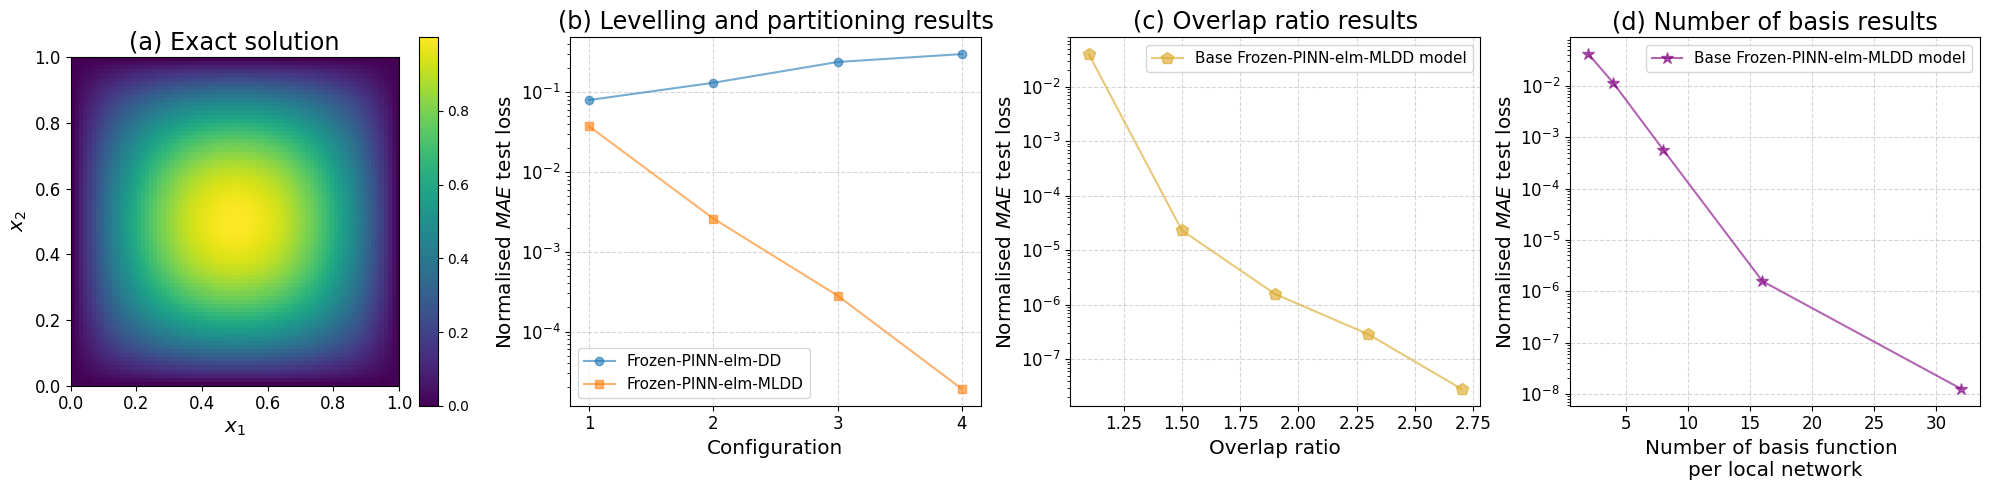

In [61]:
from matplotlib.ticker import MaxNLocator

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

# (a) Exact solution of the homogeneous Laplacian problem.
x = train_targets.reshape(NUM_TRAIN_POINTS_PER_DIM, -1)
vmin = np.nanmin(x)
vmax = np.nanmax(x)
im = axs[0].imshow(x, extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax, origin='lower', cmap='viridis')
fig.colorbar(im, ax=axs[0])
axs[0].set_title("(a) Exact solution", fontsize="xx-large")
axs[0].set_xlabel(r'$x_1$', fontsize="x-large")
axs[0].set_ylabel(r'$x_2$', fontsize="x-large")
axs[0].tick_params(axis="both", labelsize=12)

# (b) Level and partitioning configuration results
markers = ['o', 's']
ax_idx = 0
naming_convention = {"SWIM_PDE_DD": "Frozen-PINN-elm-DD", "SWIM_PDE_MLDD": "Frozen-PINN-elm-MLDD"}
for model_type, model_configs in partitioning_configs.items():
    plot_dict = {}
    conf_idx = 1
    for model_name, model_config in model_configs.items():
        plot_dict[conf_idx] = model_config['loss']
        conf_idx += 1
    axs[1].plot(plot_dict.keys(), plot_dict.values(), label=f'{naming_convention[model_type]}', marker=markers[ax_idx], alpha=0.6)
    ax_idx += 1
axs[1].set_title('(b) Levelling and partitioning results', fontsize="xx-large")    
axs[1].set_yscale('log')
axs[1].set_xlabel("Configuration", fontsize="x-large")
axs[1].set_ylabel(r'Normalised $MAE$ test loss', fontsize="x-large")
axs[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axs[1].legend(fontsize=11)
axs[1].tick_params(axis="both", labelsize=12)
axs[1].grid(True, linestyle='--', alpha=0.5)


# (c) Overlap results
plot_dict = {}
for overlap, log in overlapping_configs.items():
    plot_dict[overlap] = log['loss']
axs[2].plot(plot_dict.keys(), plot_dict.values(), label=f'Base Frozen-PINN-elm-MLDD model', marker='p', color='goldenrod', markersize=9, alpha=0.6)
axs[2].set_title('(c) Overlap ratio results', fontsize="xx-large")  
axs[2].set_yscale('log')
axs[2].set_xlabel("Overlap ratio", fontsize="x-large")
axs[2].set_ylabel(r'Normalised $MAE$ test loss', fontsize="x-large")
axs[2].legend(fontsize=11)
axs[2].tick_params(axis="both", labelsize=12)
axs[2].grid(True, linestyle='--', alpha=0.5)

# (d) Network capacity configurations result
plot_dict = {}
for num_basis, log in basis_configs.items():
    plot_dict[num_basis] = log['loss']
basis = list(plot_dict.keys())
losses = list(plot_dict.values())
axs[3].plot(basis, losses, label=f'Base Frozen-PINN-elm-MLDD model', marker='*', color='purple', markersize=9, alpha=0.6)
axs[3].set_title('(d) Number of basis results', fontsize="xx-large")  
axs[3].set_yscale('log')
axs[3].set_xlabel("Number of basis function \nper local network", fontsize="x-large")
axs[3].set_ylabel(r'Normalised $MAE$ test loss', fontsize="x-large")
axs[3].legend(fontsize=11)
axs[3].tick_params(axis="both", labelsize=12)
axs[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Evaluation

We can report the following observations for this experiment where we test the effect of different partitioning and number of levels on prediction accuracy both for onelevel and multilevel SWIM-PDE models.

1. MultiLevel models have higher accuracies comparing with onelevel models with same number of partition at final level (see SubFigure b). This indicates that multilevel SWIM-PDE models can capture different resolutional contents from the solutions succesfully and yields better global predictions.
2. Having more levels increase the prediction accuracy in this experiment for SWIM-PDE-MLDD models (see SubFigure b).
3. Having more partition increase the prediction accuracy in this experiment for SWIM-PDE-MLDD models (see SubFigure b).
4. Increasing overlapping ratio tends to increase the prediction accuracy, probably due to better communications between subdomain networks (see SubFigure c).
5. Increasing the number of basis functions for each subdomain network increases the prediction accuracy as long as the model needs more capacity to approximate underlying solution content (see SubFigure d).